In [ ]:
# medical tabular: keep a simple sklearn baseline first
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score
import matplotlib.pyplot as plt

In [ ]:
# Загружаем данные
df = pd.read_csv("CTG.csv")

df.head()

,FileName,Date,SegFile,b,e,LBE,LB,AC,FM,UC,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
0,Variab10.txt,12/1/1996,CTG0001.txt,240.0,357.0,120.0,120.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,2.0
1,Fmcs_1.txt,5/3/1996,CTG0002.txt,5.0,632.0,132.0,132.0,4.0,0.0,4.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
2,Fmcs_1.txt,5/3/1996,CTG0003.txt,177.0,779.0,133.0,133.0,2.0,0.0,5.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
3,Fmcs_1.txt,5/3/1996,CTG0004.txt,411.0,1192.0,134.0,134.0,2.0,0.0,6.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
4,Fmcs_1.txt,5/3/1996,CTG0005.txt,533.0,1147.0,132.0,132.0,4.0,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0


In [ ]:
# 1. Анализ корреляции - удаляем признаки с очень высокой корреляцией (>0.95)
correlation_matrix = df_cleaned.corr()
high_corr_features = set()

for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > 0.95:  # Если корреляция больше 0.95
            colname = correlation_matrix.columns[i]
            high_corr_features.add(colname)

# 2. Анализ дисперсии - удаляем признаки с низким разбросом значений
low_variance_features = [col for col in df_cleaned.columns if df_cleaned[col].nunique() < 3]

# Объединяем признаки, которые можно удалить
features_to_drop = list(high_corr_features.union(low_variance_features))

# Выводим список признаков, которые можно удалить
features_to_drop

['E', 'DE', 'LD', 'AD', 'B', 'DS', 'C', 'FS', 'D', 'SUSP', 'A', 'LB', 'DR']

In [ ]:
# Удаляем ненужные столбцы, включая найденные избыточные признаки
df_cleaned = df.drop(columns=["FileName", "Date", "SegFile", "CLASS", "b", "e", "Min", "Max", "Width"] + features_to_drop)

# Заполняем пропущенные значения медианой
df_cleaned.fillna(df_cleaned.median(), inplace=True)

# Проверяем итоговые данные
df_cleaned.info(), df_cleaned.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2129 entries, 0 to 2128
Data columns (total 18 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LBE       2129 non-null   float64
 1   AC        2129 non-null   float64
 2   FM        2129 non-null   float64
 3   UC        2129 non-null   float64
 4   ASTV      2129 non-null   float64
 5   MSTV      2129 non-null   float64
 6   ALTV      2129 non-null   float64
 7   MLTV      2129 non-null   float64
 8   DL        2129 non-null   float64
 9   DP        2129 non-null   float64
 10  Nmax      2129 non-null   float64
 11  Nzeros    2129 non-null   float64
 12  Mode      2129 non-null   float64
 13  Mean      2129 non-null   float64
 14  Median    2129 non-null   float64
 15  Variance  2129 non-null   float64
 16  Tendency  2129 non-null   float64
 17  NSP       2129 non-null   float64
dtypes: float64(18)
memory usage: 299.5 KB


(None,
      LBE   AC   FM   UC  ASTV  MSTV  ALTV  MLTV   DL   DP  Nmax  Nzeros  \
 0  120.0  0.0  0.0  0.0  73.0   0.5  43.0   2.4  0.0  0.0   2.0     0.0   
 1  132.0  4.0  0.0  4.0  17.0   2.1   0.0  10.4  2.0  0.0   6.0     1.0   
 2  133.0  2.0  0.0  5.0  16.0   2.1   0.0  13.4  2.0  0.0   5.0     1.0   
 3  134.0  2.0  0.0  6.0  16.0   2.4   0.0  23.0  2.0  0.0  11.0     0.0   
 4  132.0  4.0  0.0  5.0  16.0   2.4   0.0  19.9  0.0  0.0   9.0     0.0   
 
     Mode   Mean  Median  Variance  Tendency  NSP  
 0  120.0  137.0   121.0      73.0       1.0  2.0  
 1  141.0  136.0   140.0      12.0       0.0  1.0  
 2  141.0  135.0   138.0      13.0       0.0  1.0  
 3  137.0  134.0   137.0      13.0       1.0  1.0  
 4  137.0  136.0   138.0      11.0       1.0  1.0  )

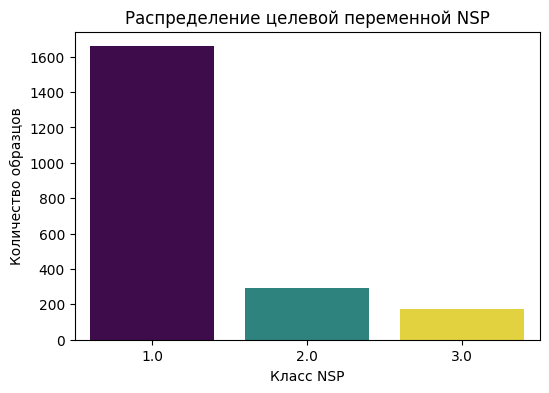

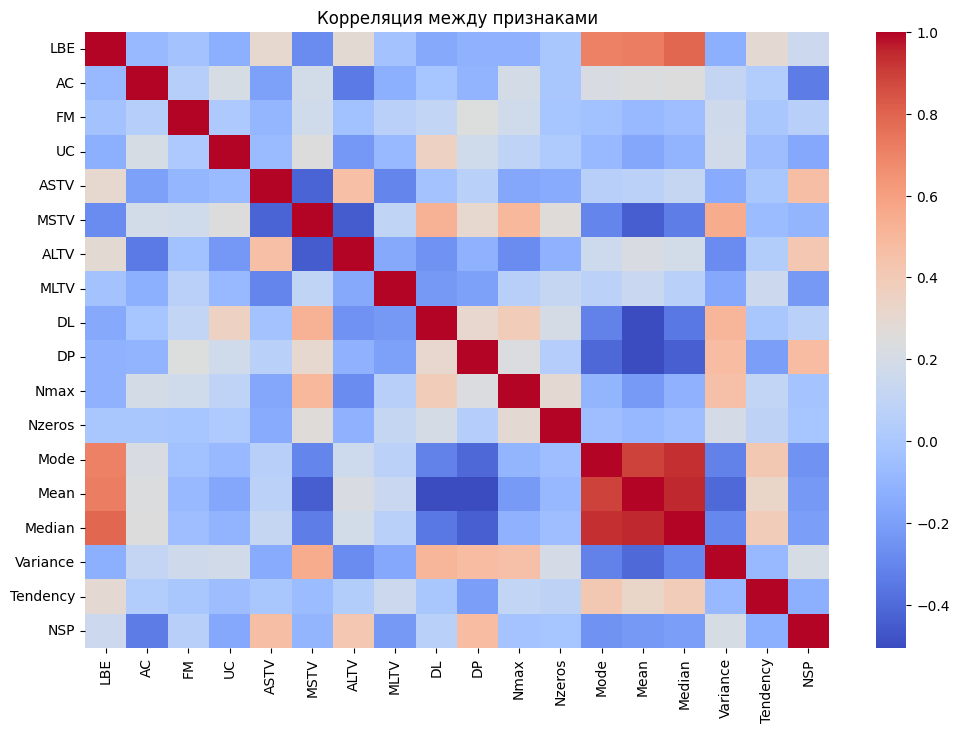

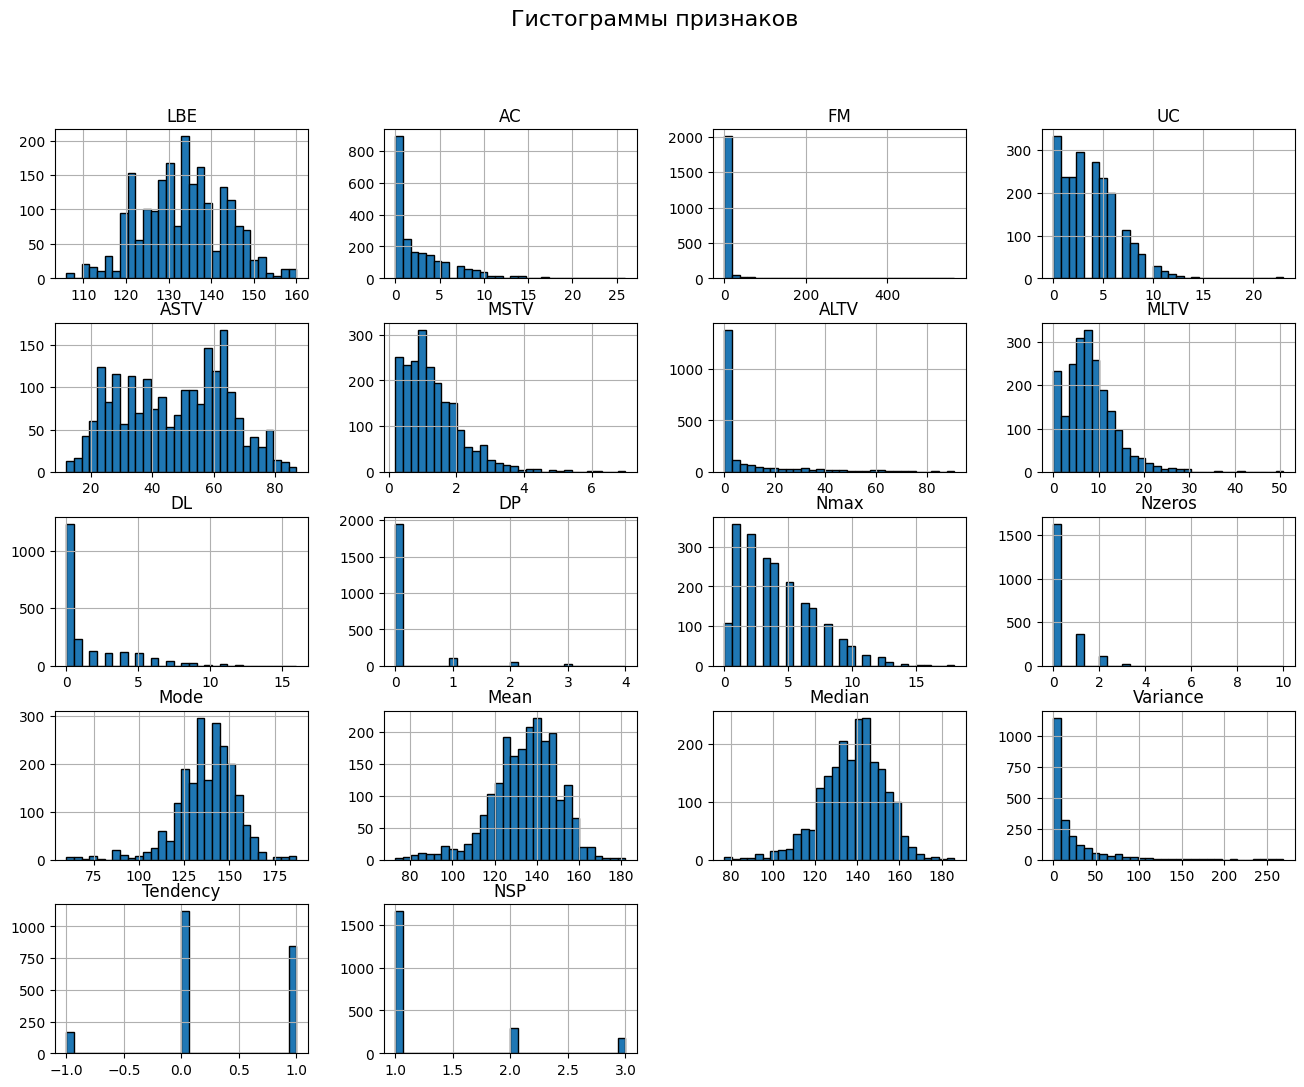

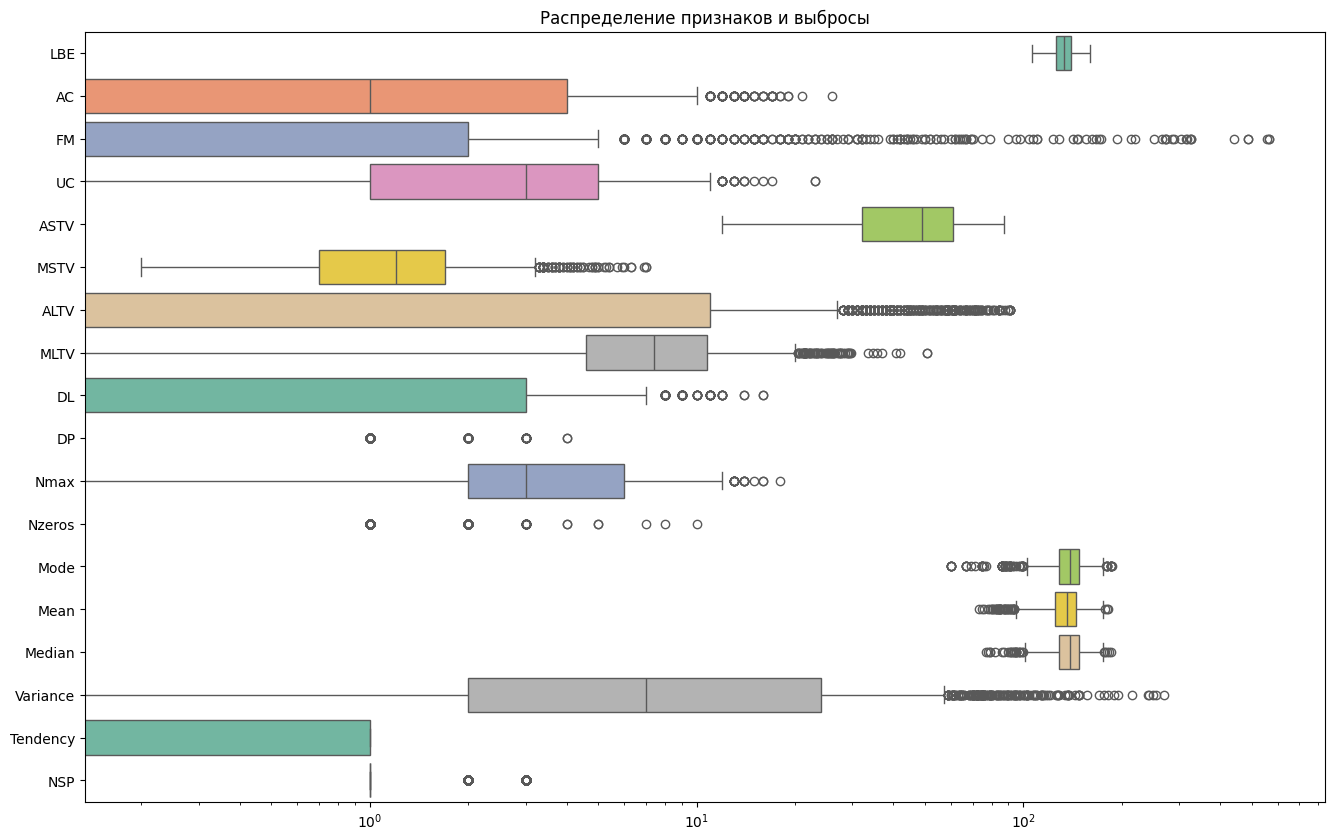

In [ ]:
# Анализ данных перед созданием модели
import matplotlib.pyplot as plt
import seaborn as sns

# Проверим количество уникальных значений в целевой переменной NSP
nsp_counts = df_cleaned["NSP"].value_counts()

# Визуализируем распределение классов NSP
plt.figure(figsize=(6, 4))
sns.barplot(x=nsp_counts.index, y=nsp_counts.values, hue=nsp_counts.index, palette="viridis", legend=False)
plt.xlabel("Класс NSP")
plt.ylabel("Количество образцов")
plt.title("Распределение целевой переменной NSP")
plt.show()

# Проверяем корреляцию между признаками
correlation_matrix = df_cleaned.corr()

# Тепловая карта корреляции
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, cmap="coolwarm", annot=False)
plt.title("Корреляция между признаками")
plt.show()

# Проверка распределения основных числовых признаков
df_cleaned.hist(figsize=(16, 12), bins=30, edgecolor="black")
plt.suptitle("Гистограммы признаков", fontsize=16)
plt.show()

# Проверим выбросы с помощью boxplot
plt.figure(figsize=(16, 10))
sns.boxplot(data=df_cleaned, orient="h", palette="Set2")
plt.xscale("log")
plt.title("Распределение признаков и выбросы")
plt.show()


In [ ]:
# Разделяем на признаки и целевую переменную
X = df_cleaned.drop(columns=["NSP"])
y = df_cleaned["NSP"].astype(int)

# Нормализация признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Разделение на тренировочный и тестовый наборы
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Преобразуем метки классов в one-hot encoding
y_train_encoded = keras.utils.to_categorical(y_train - 1, num_classes=3)
y_test_encoded = keras.utils.to_categorical(y_test - 1, num_classes=3)

In [ ]:
# Создаём модель
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dense(3, activation="softmax")
])

# Компиляция модели с F1-score
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# Обучение модели
history = model.fit(X_train, y_train_encoded, validation_data=(X_test, y_test_encoded),
                    epochs=50, batch_size=32, verbose=1)

# Предсказания вероятностей классов
y_pred_prob = model.predict(X_test)

# Конвертируем вероятности в метки классов
y_pred_classes = np.argmax(y_pred_prob, axis=1) + 1

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7601 - loss: 0.7339 - val_accuracy: 0.8732 - val_loss: 0.3675
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8545 - loss: 0.3812 - val_accuracy: 0.8756 - val_loss: 0.2971
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8673 - loss: 0.3267 - val_accuracy: 0.8944 - val_loss: 0.2627
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8733 - loss: 0.3086 - val_accuracy: 0.8779 - val_loss: 0.2702
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8906 - loss: 0.2616 - val_accuracy: 0.8920 - val_loss: 0.2385
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8898 - loss: 0.2580 - val_accuracy: 0.9061 - val_loss: 0.2357
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9089 - loss: 0.2432 - val_accuracy: 0.9038 - val_loss: 0.2311
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9029 - loss: 0.2430 - val_accuracy: 0.9038 - val_loss

In [ ]:
# Вычисление ROC-AUC для многоклассовой классификации
auc = roc_auc_score(y_test_encoded, y_pred_prob, multi_class="ovr")
print(f"ROC-AUC Score: {auc:.4f}")

ROC-AUC Score: 0.9859


In [ ]:
# Вычисление F1-score (макро и микро)
f1_macro = f1_score(y_test, y_pred_classes, average="macro")
f1_micro = f1_score(y_test, y_pred_classes, average="micro")
print(f"F1-score (Macro): {f1_macro:.4f}")
print(f"F1-score (Micro): {f1_micro:.4f}")


F1-score (Macro): 0.8533
F1-score (Micro): 0.9272


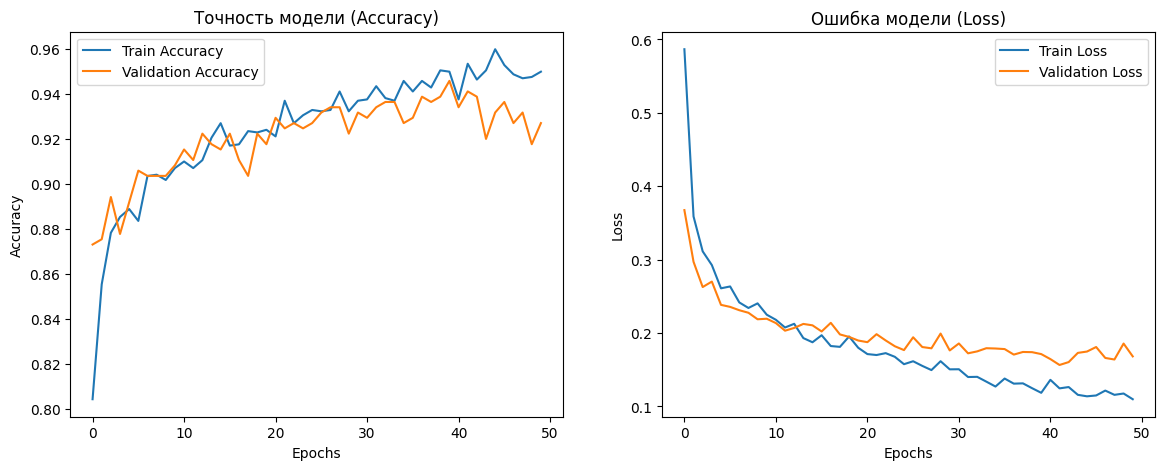

In [ ]:
# --- Графики ---
plt.figure(figsize=(14, 5))

# График Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Точность модели (Accuracy)")

# График Loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Ошибка модели (Loss)")

plt.show()